In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.12'

file_007


(0.99, 1.015)

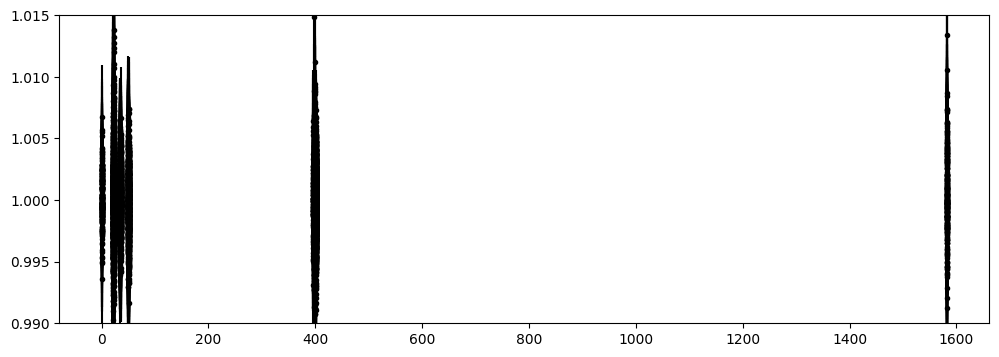

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 5
file_to_use = all_files[i]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]
print(name)

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = name,
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ

<🌟 Lightcurve file_007 (6970t) 🌟>

In [81]:
targ_with_transit = targ.inject_transit(per=2*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=2 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

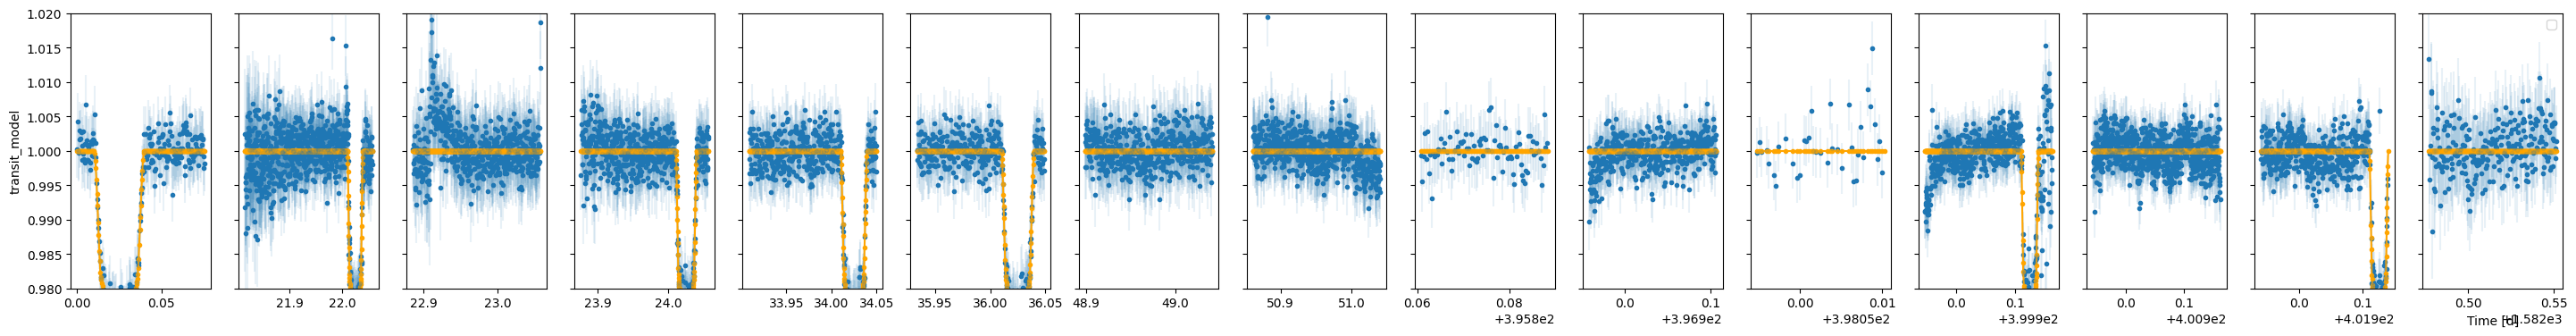

In [82]:
ax=targ_with_transit.plot(ylims=[0.95,1.05])
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-",)

In [112]:
self = targ_with_transit
nan_mask = ~np.isnan(self.flux)
BLS_d = BoxLeastSquares(self.time.value[nan_mask], self.flux[nan_mask], dy=self.uncertainty[nan_mask])
# pg_d = BLS_d.power(periods, transit_durations, objective=obj, oversample=oversample)
periods = np.logspace(
            np.log10(0.5),
            np.log10(30),
            10000
        )

pg_d = BLS_d.power(periods, [0.01,0.02,0.03,0.04], 
                       objective="snr", 
                       oversample=100, )
                   # minimum_period=2,
                       # maximum_period=30, 
                       # minimum_n_transit=2)

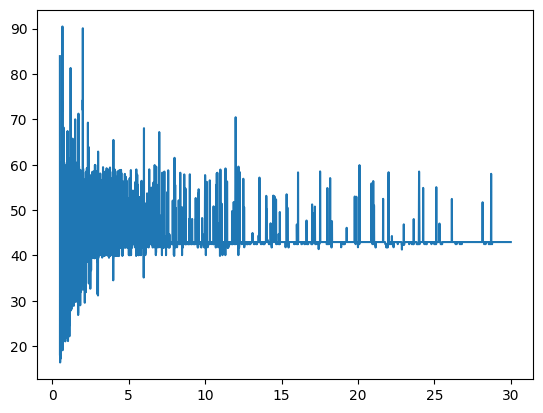

In [114]:
plt.plot(periods, pg_d.power)

In [84]:
# self = targ_with_transit
# obj="snr"
# oversample=30
# minimum_period=2
# maximum_period=30
# minimum_n_transit=2
# transit_durations = [0.01,0.02,0.03,0.04]

# nan_mask = np.isfinite(self.flux)

# # KEY OPTIMIZATION: Segment data by large gaps
# time_vals = self.time.value[nan_mask]
# time_diffs = np.diff(time_vals)
# gap_threshold = 0.5  # days - adjust based on your data
# large_gaps = np.where(time_diffs > gap_threshold)[0]

# # Adjust maximum period to data span
# data_span = time_vals[-1] - time_vals[0]
# maximum_period = min(maximum_period, data_span / 2)

# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=AstropyWarning)
    
#     BLS_d = BoxLeastSquares(
#         time_vals, 
#         self.flux[nan_mask], 
#         dy=self.uncertainty[nan_mask]
#     )
    
#     pg_d = BLS_d.autopower(
#         transit_durations, 
#         objective=obj, 
#         oversample=max(5, oversample),  # Don't go below 5
#         frequency_factor=5.0,  # KEY: 3-10 for speed, 1 for accuracy
#         minimum_period=minimum_period,
#         maximum_period=maximum_period, 
#         minimum_n_transit=minimum_n_transit
#     )



Running BLS Search with segment handling
Found 2 large gaps, processing 3 segments
Found 3 segments
Using 10000 periods from 0.500 to 30.000 days
  Segment 1: 4280 points, span 51.04 days, testing 9605 periods
  Segment 2: 2411 points, span 6.18 days, testing 4448 periods

Combined results:
  Best period: 0.6668 days
  Max power: 89.85
  From segment: 1

Per-segment best results:
  Segment 1: period=0.6668d, power=89.85
  Segment 2: period=2.0045d, power=59.41
Best period: 0.6668 days
Max power: 89.85


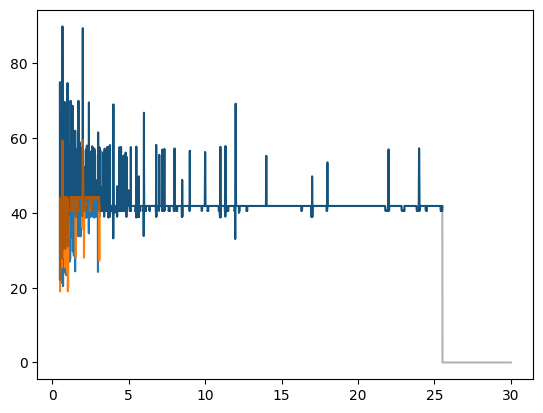

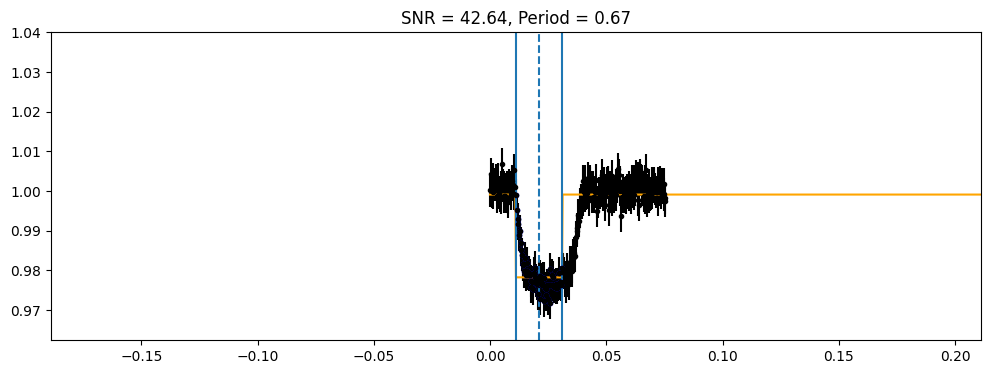

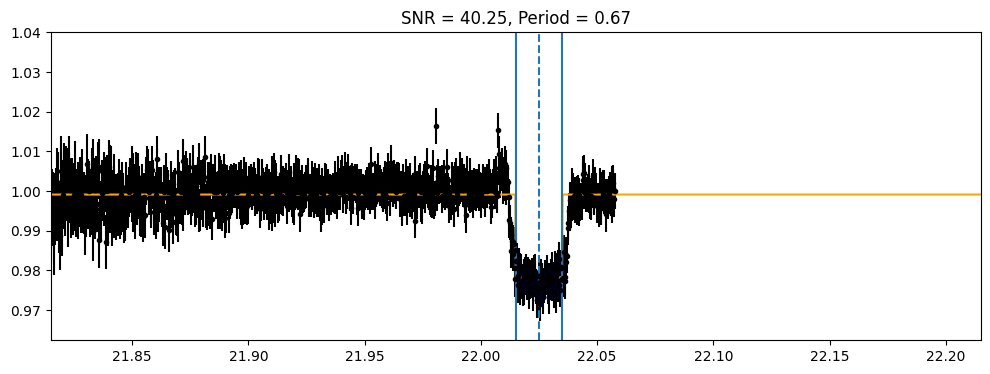

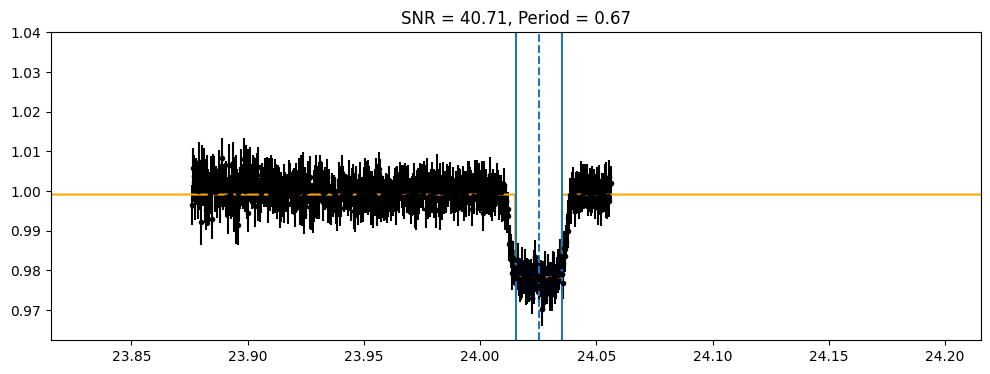

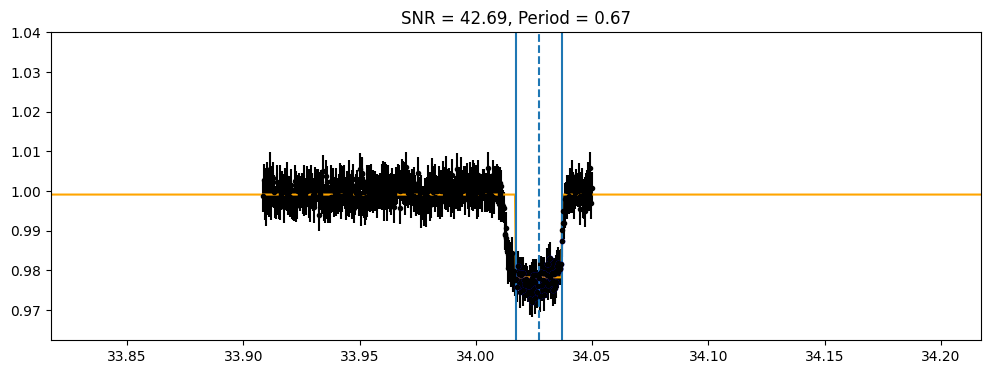

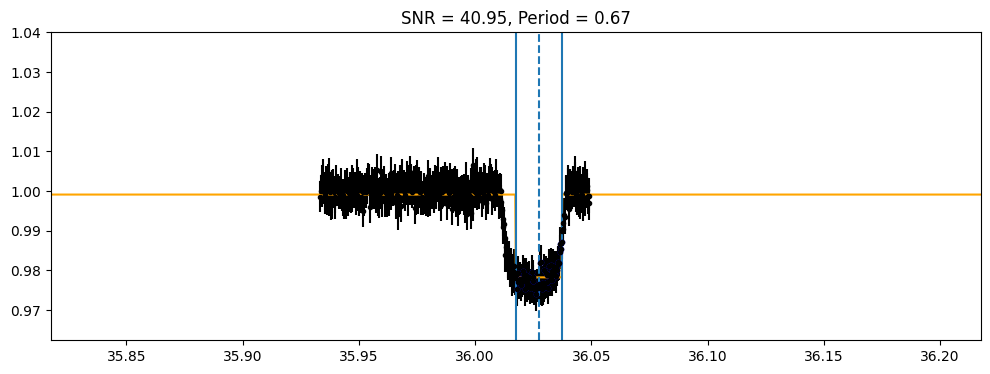

In [104]:
self = targ_with_transit
obj="snr"
oversample=30
minimum_period=0.5
maximum_period=30
minimum_n_transit=2
transit_durations = [0.01,0.02,0.03,0.04]

# results = bls_with_gap_removal(targ_with_transit, 
#                             transit_durations,
#                             minimum_period, 
#                             maximum_period,
#                             oversample=30,
#                             gap_threshold=30,
#                             objective="snr",
#                             minimum_n_transit=2,
#                            verbose=True, plot=True)

res = find_transits(targ_with_transit, 
                            transit_durations,
                            minimum_period, 
                            maximum_period,
                            oversample=30,
                            gap_threshold=100,
                            obj="snr",
                            minimum_n_transit=2,
                           verbose=True, plot=True)

# pers, power_d, epoch_d, depth_d, durs = pg_d.period, pg_d.power, pg_d.transit_time, pg_d.depth, pg_d.duration

In [22]:
# res2[1]

Running BLS Search with segment handling
Found 2 large gaps, processing 3 segments
Found 3 segments
Using 10000 periods from 0.500 to 30.000 days
  Segment 1: 4280 points, span 51.04 days, testing 9605 periods
  Segment 2: 2411 points, span 6.18 days, testing 4448 periods

Combined results:
  Best period: 0.6668 days
  Max power: 89.85
  From segment: 1

Per-segment best results:
  Segment 1: period=0.6668d, power=89.85
  Segment 2: period=2.0045d, power=59.41
Best period: 0.6668 days
Max power: 89.85


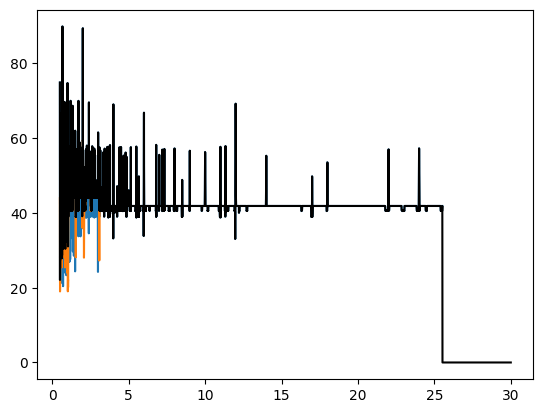

In [99]:
# freq_grid = np.linspace(1/30, 1/0.5, 100)
# period_grid = 1/freq_grid
# res2 = bls_with_segment_combination(self, transit_durations, minimum_period, maximum_period=5,
#                                 gap_threshold=5, obj='likelihood', oversample=10,
#                                 frequency_factor=3.0, minimum_n_transit=2, 
#                                 minpower=5, verbose=False, period_grid=period_grid)
# # combined_result, all_periods, all_powers
# plt.plot(res2[1][0], res2[2][0])
# plt.plot(res2[1][1], res2[2][1])
# plt.plot(res2[1][2], res2[2][2])
# plt.plot(res2[1][3], res2[2][3])
# plt.plot(res2[3], res2[4], 'k')

# In your find_transits or wherever you call bls:
bls_f_model_all, transit_params_all, stats_all, BLS_obj = bls_optimized_with_segments(
    self,
    transit_durations=transit_durations,
    minimum_period=minimum_period,
    maximum_period=30,
    limitperiod=False,
    obj=obj,
    oversample=oversample,
    minpower=5,
    return_all_transits=False,
    minimum_n_transit=minimum_n_transit,
    verbose=True,
    gap_threshold=30,      # Adjust for your data
    n_periods=10000,         # More = finer grid but slower
    plot=True,
)

In [32]:
# res[0].metadata

In [101]:
def find_transits(self, transit_durations=0.01, minimum_period=0.5, maximum_period=30, limitperiod=False,
                  obj='likelihood', oversample=30.0, minpower=5, return_all_transits=False,
                  minimum_n_transit=3, plot=False, figsize=(12, 4), verbose=False, save_plots=False,
                  plot_dir="", i_lc=0, plot_kw={'ylims': [0.95, 1.05]}, gap_threshold=30,):

    transit_pd = {"period": [], "depth": [], 'duration': [], 'epoch': [], 'epoch_start': [], 'epoch_end': [], 'snr': []}


    # bls_f_model_all, transit_params_all, stats_all, BLS_obj = bls_with_gap_removal(self, transit_durations=transit_durations,
    #                                                        minimum_period= minimum_period,
    #                                                        maximum_period=maximum_period,
    #                                                        limitperiod=limitperiod,
    #                                                        objective=obj,
    #                                                        oversample=oversample,
    #                                                        minpower=minpower,
    #                                                        gap_threshold=gap_threshold,
    #                                                        return_all_transits=return_all_transits,
    #                                                        minimum_n_transit=minimum_n_transit,
    #                                                        save_plots=False,
    #                                                        verbose=verbose)

    bls_f_model_all, transit_params_all, stats_all, BLS_obj = bls_optimized_with_segments(
        self,
        transit_durations=transit_durations,
        minimum_period=minimum_period,
        maximum_period=maximum_period,
        limitperiod=limitperiod,
        obj=obj,
        oversample=oversample,
        minpower=minpower,
        return_all_transits=False,
        minimum_n_transit=minimum_n_transit,
        verbose=verbose,
        gap_threshold=gap_threshold,      # Adjust for your data
        n_periods=10000,         # More = finer grid but slower
        plot=plot,
    )

    # Pre-compute time array with units once
    time_with_units = self.time.value * u.d

    bls_lightcurve_all = []
    for i, (bls_f_model, transit_params, stats) in enumerate(zip(bls_f_model_all, transit_params_all, stats_all)):
        bls_lightcurve = self._create_copy()

        if len(stats) > 0:
            bls_transits = stats['per_transit_count']
            # transits = np.where(np.array(bls_f_model) < np.nanmedian(bls_f_model))[0]
            transits = np.where(bls_f_model < np.nanmedian(bls_f_model))[0]

            # trans_num = 0
            transit_found = True
            if len(bls_transits) > 0:
                # Pre-extract transit parameters (avoid repeated indexing)
                period_val = transit_params[0] * u.d
                duration_val = transit_params[2] * u.d
                half_duration = 0.5 * duration_val
                
                # Vectorize transit processing
                transit_times = stats['transit_times'] * u.d
                valid_transits = bls_transits > 0
                
                if np.any(valid_transits):
                    # Process all valid transits at once
                    valid_indices = np.where(valid_transits)[0]
                    mid_transits = transit_times[valid_indices]
                    transit_starts = mid_transits - half_duration
                    transit_ends = mid_transits + half_duration
                
                    recovered_depth = stats['depth'][0]
                
                    # Vectorized search for start/end indices using searchsorted (much faster than where)
                    i_starts = np.searchsorted(time_with_units.value, transit_starts.value)
                    i_ends = np.searchsorted(time_with_units.value, transit_ends.value, side='right') - 1
                
                    # Ensure indices are valid
                    i_starts = np.clip(i_starts, 0, len(self.uncertainty) - 1)
                    i_ends = np.clip(i_ends, 0, len(self.uncertainty) - 1)
                
                    # Compute SNR for all transits
                    for j, (b_idx, mid_transit, transit_start, transit_end, i_start, i_end) in enumerate(
                            zip(valid_indices, mid_transits, transit_starts, transit_ends, i_starts, i_ends)
                    ):
                        if i_end > i_start:  # Ensure valid range
                            unc = np.nanmedian(self.uncertainty[i_start:i_end + 1])
                            snr = (recovered_depth * np.sqrt(bls_transits[b_idx])) / unc
                        else:
                            unc = np.nanmedian(self.uncertainty)
                            snr = (recovered_depth * np.sqrt(bls_transits[b_idx])) / unc
                
                            # Append results
                            transit_pd["period"].append(period_val)
                            transit_pd["depth"].append(recovered_depth)
                            transit_pd['duration'].append(transit_end - transit_start)
                            transit_pd['epoch'].append(mid_transit)
                            transit_pd['epoch_start'].append(transit_start)
                            transit_pd['epoch_end'].append(transit_end)
                            transit_pd['snr'].append(snr)
                
                        if plot:
                            plt.figure(figsize=figsize)
                            plt.errorbar(self.time.value, self.flux, self.uncertainty, color='k', fmt='.')
                            plt.plot(self.time.value, bls_f_model, 'orange')
                            plt.axvline(transit_start.value)
                            plt.axvline(transit_end.value)
                            plt.axvline(mid_transit.value, linestyle='--')
                            plt.plot(self.time.value[transits], self.flux[transits], 'b.')
                            plt.title(f"SNR = {snr:.2f}, Period = {period_val.value:.2f}")
                            plt.xlim(transit_start.value - 0.2, transit_start.value + 0.2)
                            if save_plots:
                                plt.savefig(f"{plot_dir}/{self.name}_bls")
                                plt.close()
                            else:
                                plt.show()
                                plt.close()
                            # plt.show()
                            # plt.close()
                else:
                    transit_found = False
                    transits = []
        else:
            transit_found=False
            transits = []

        bls_lightcurve.timelike['flux'] = self.timelike['flux'] / bls_f_model
        bls_lightcurve.timelike['BLS_model'] = bls_f_model
        bls_lightcurve.metadata['BLS_transits_found'] = transit_found
        bls_lightcurve.metadata['BLS_transits_ind'] = transits
        bls_lightcurve.metadata['BLS_transits_params'] = transit_pd

        bls_lightcurve._set_name(bls_lightcurve.name + f"_bls_{i}")

        bls_lightcurve_all.append(bls_lightcurve)

    return bls_lightcurve_all

In [103]:
def bls_with_gap_removal(self, transit_durations, minimum_period, maximum_period, 
                        gap_threshold=0.5,verbose=False, plot=True, minpower=5,
                         return_all_transits=False, save_plots=False, limitperiod=False,
                         **kwargs):
    """
    Remove large gaps before running BLS - this is often the biggest speedup.
    
    Parameters:
    -----------
    gap_threshold : float
        Time gap threshold in days. Points separated by more than this 
        are treated as separate observing seasons.
    """
    
    # Find large gaps
    time_vals = self.time.value if hasattr(self.time, 'value') else self.time
    time_diffs = np.diff(time_vals)
    large_gaps = np.where(time_diffs > gap_threshold)[0]
    
    # Create segments without large gaps
    split_indices = np.concatenate([[0], large_gaps + 1, [len(time_vals)]])
    print(f"# of segments = {len(split_indices)}")
    
    all_results = []
    all_BLS_segs = []

    plt.figure()
    # plt.plot(self.time.value, self.flux)
    
    for i in range(len(split_indices)-1):
        # if i == len(split_indices):
        #     start, end = split_indices[i], -1
        # else:
        start, end = split_indices[i], split_indices[i + 1]
        
        # Skip very short segments
        if end - start < 10:
            continue
        
        # Extract segment
        t_seg = time_vals[start:end]
        flux_seg = self.flux[start:end]
        unc_seg = self.uncertainty[start:end]
        # plt.plot(t_seg, flux_seg)
         
        # Remove NaNs
        mask = np.isfinite(flux_seg)
        if np.sum(mask) < 10:
            continue
        
        # Run BLS on this segment
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=AstropyWarning)
            
            BLS_seg = BoxLeastSquares(t_seg[mask], flux_seg[mask], dy=unc_seg[mask])
            
            # Adjust maximum period for segment length
            seg_duration = t_seg[-1] - t_seg[0]
            max_per_seg = min(maximum_period, seg_duration / 2)
            
            if max_per_seg > minimum_period:
                result = BLS_seg.autopower(
                    transit_durations,
                    minimum_period=minimum_period,
                    maximum_period=max_per_seg,
                    **kwargs
                )
                all_results.append((result, start, end))
                all_BLS_segs.append(BLS_seg)

                plt.plot(result.period, result.power, label=i)
            
    plt.legend()
    # print(all_results)
    
    # Combine results - find global maximum
    if not all_results:
        return None
    
    best_power = -np.inf
    best_result = None
    
    for i,(result, start, end) in enumerate(all_results):
        print(start, end, np.nanmax(result.power))
        max_power = np.nanmax(result.power)
        if max_power > best_power:
            best_power = max_power
            best_result = result
            best_BLS = all_BLS_segs[i]

    pers, power_d, epoch_d, depth_d, durs = best_result.period, best_result.power, best_result.transit_time, best_result.depth, best_result.duration
    max_power = np.argmax(power_d)

    if verbose:
        print("Number of Periods Checked: ", len(pers))
        print("Period: ", pers[max_power])
        print("Duration: ", durs[max_power])
        print("Depth: ", depth_d[max_power])
        print("Power: ", power_d[max_power])

    sorted_ind_power = np.argsort(power_d)[::-1]

    if np.count_nonzero(np.isfinite(power_d)) > 0:
        if power_d[max_power] > minpower:
            if return_all_transits:
                i = 0
                allpers, allt0s, alldurs, alldepths, allstats, allf_models = [],[],[],[],[],[]
                power_ind = sorted_ind_power[0]
                if plot:
                    plt.figure()
                    plt.plot(pers, power_d)
                while power_d[power_ind] > minpower:
                    if plot:
                        plt.plot(pers[power_ind], power_d[power_ind], 'rx')
                    allpers.append(pers[power_ind])
                    allt0s.append(epoch_d[power_ind])
                    alldurs.append(durs[power_ind])
                    alldepths.append(depth_d[power_ind])
                    allstats.append(best_BLS.compute_stats(allpers[-1], alldurs[-1], allt0s[-1]))

                    allf_models.append(best_BLS.model(t_model=self.time.value, period=allpers[-1], duration=alldurs[-1],
                                          transit_time=allt0s[-1]))
                    i += 1
                    power_ind = sorted_ind_power[i]
                    print(i, power_ind, )
                return allf_models, \
                    [[ap, at, ad, ade] for ap, at, ad, ade in zip(allpers, allt0s, alldurs, alldepths)], allstats, best_BLS
            else:
                best_per_d = pers[max_power]
                best_t0_d = epoch_d[max_power]
                best_dur_d = durs[max_power]
                best_depth_d = depth_d[max_power]
                stats = best_BLS.compute_stats(best_per_d, best_dur_d, best_t0_d)

                f_model = best_BLS.model(t_model=self.time.value, period=best_per_d, duration=best_dur_d, transit_time=best_t0_d)

                if plot:
                    power_ind = sorted_ind_power[0]
                    plt.figure()
                    plt.plot(pers, power_d)
                    plt.plot(pers[power_ind], power_d[power_ind], 'rx')
                
                return [f_model], [[best_per_d, best_t0_d, best_dur_d, best_depth_d]], [stats], best_BLS

            if plot:
                if save_plots:
                    plt.savefig(f"{plot_dir}/{self.name}_bls_periodogram")
                    plt.close()
                else:
                    plt.show()
                    plt.close()
        else:
            if verbose:
                print("No transits detected!")
            return np.ones(len(self.time)), [], [], []

    else:
        if verbose:
            print("No transits detected!")
        return np.ones(len(self.time)), [], [], []
        
    return best_result


# ============================================================================
# Strategy 1: Combine all segment results and re-rank
# ============================================================================
def bls_with_segment_combination(self, transit_durations, minimum_period, maximum_period,
                                gap_threshold=0.5, obj='likelihood', oversample=10,
                                frequency_factor=3.0, minimum_n_transit=3, 
                                minpower=5, n_periods=10000, verbose=False):
    """
    Run BLS on each segment separately using a common period grid.
    Returns merged power spectrum with transits from all segments.
    
    Parameters:
    -----------
    n_periods : int
        Number of periods in the grid. More = slower but finer resolution.
    """
    
    time_vals = self.time.value if hasattr(self.time, 'value') else self.time
    nan_mask = np.isfinite(self.flux)
    
    # Find segments
    time_diffs = np.diff(time_vals[nan_mask])
    large_gaps = np.where(time_diffs > gap_threshold)[0]
    split_indices = np.concatenate([[0], large_gaps + 1, [np.sum(nan_mask)]])
    
    if verbose:
        print(f"Found {len(split_indices) - 1} segments")
    
    # Create common period grid - use frequency spacing if frequency_factor provided
    if frequency_factor is not None and frequency_factor > 1:
        # Logarithmic spacing (better for wide period ranges)
        common_periods = np.logspace(
            np.log10(minimum_period),
            np.log10(maximum_period),
            n_periods
        )
    else:
        # Linear spacing
        common_periods = np.linspace(minimum_period, maximum_period, n_periods)
    
    if verbose:
        print(f"Using {len(common_periods)} periods from {minimum_period:.3f} to {maximum_period:.3f} days")
    
    # Initialize combined arrays
    combined_power = np.full(len(common_periods), -np.inf)
    combined_duration = np.zeros(len(common_periods))
    combined_depth = np.zeros(len(common_periods))
    combined_t0 = np.zeros(len(common_periods))
    best_segment = np.zeros(len(common_periods), dtype=int)
    segment_info = []
    all_powers = []
    all_periods = []
    
    # Process each segment
    for i in range(len(split_indices) - 1):
        start, end = split_indices[i], split_indices[i + 1]
        
        # Skip short segments
        if end - start < 10:
            continue
        
        # Get indices in original (non-masked) array
        masked_indices = np.where(nan_mask)[0]
        seg_indices = masked_indices[start:end]
        
        t_seg = time_vals[seg_indices]
        flux_seg = self.flux[seg_indices]
        unc_seg = self.uncertainty[seg_indices]
        
        # Additional NaN check for this segment
        seg_mask = np.isfinite(flux_seg)
        if np.sum(seg_mask) < 10:
            continue
        
        seg_duration = t_seg[seg_mask][-1] - t_seg[seg_mask][0]
        
        # Filter period grid to valid range for this segment
        max_per_seg = min(maximum_period, seg_duration / 2)
        valid_periods_mask = (common_periods >= minimum_period) & (common_periods <= max_per_seg)
        
        if not np.any(valid_periods_mask):
            continue
        
        periods_for_seg = common_periods[valid_periods_mask]
        
        if verbose:
            print(f"  Segment {i+1}: {len(t_seg[seg_mask])} points, "
                  f"span {seg_duration:.2f} days, "
                  f"testing {len(periods_for_seg)} periods")
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=AstropyWarning)
            
            BLS_seg = BoxLeastSquares(
                t_seg[seg_mask], 
                flux_seg[seg_mask], 
                dy=unc_seg[seg_mask]
            )
            
            # Use BLS.power() with the common period grid
            result_seg = BLS_seg.power(
                periods_for_seg,
                transit_durations,
                objective=obj,
                oversample=oversample
            )
        
        # Update combined arrays where this segment has higher power
        seg_power = result_seg.power
        all_powers.append(seg_power)
        all_periods.append(periods_for_seg)
        better_mask = seg_power > combined_power[valid_periods_mask]
        
        # Get indices in the full array where we need to update
        update_indices = np.where(valid_periods_mask)[0][better_mask]
        
        combined_power[update_indices] = seg_power[better_mask]
        combined_duration[update_indices] = result_seg.duration[better_mask]
        combined_depth[update_indices] = result_seg.depth[better_mask]
        combined_t0[update_indices] = result_seg.transit_time[better_mask]
        best_segment[update_indices] = i
        
        segment_info.append({
            'segment_id': i,
            'start_idx': seg_indices[0],
            'end_idx': seg_indices[-1],
            'start_time': t_seg[seg_mask][0],
            'end_time': t_seg[seg_mask][-1],
            'n_points': np.sum(seg_mask),
            'max_power': np.max(seg_power),
            'best_period': periods_for_seg[np.argmax(seg_power)]
        })
    
    if len(segment_info) == 0:
        if verbose:
            print("No valid segments found")
        return None, None, None
    
    # Replace any remaining -inf with 0 (periods not tested in any segment)
    combined_power[combined_power == -np.inf] = 0
    
    # Create combined result object (mimics BLS result structure)
    class CombinedBLSResult:
        def __init__(self, period, power, duration, depth, transit_time, 
                     segment_info, best_segment):
            self.period = period
            self.power = power
            self.duration = duration
            self.depth = depth
            self.transit_time = transit_time
            self.segment_info = segment_info
            self.best_segment = best_segment
    
    combined_result = CombinedBLSResult(
        common_periods, combined_power, combined_duration, 
        combined_depth, combined_t0, segment_info, best_segment
    )
    
    if verbose:
        max_idx = np.argmax(combined_power)
        print(f"\nCombined results:")
        print(f"  Best period: {common_periods[max_idx]:.4f} days")
        print(f"  Max power: {combined_power[max_idx]:.2f}")
        print(f"  From segment: {best_segment[max_idx] + 1}")
        
        print(f"\nPer-segment best results:")
        for seg in segment_info:
            print(f"  Segment {seg['segment_id']+1}: "
                  f"period={seg['best_period']:.4f}d, "
                  f"power={seg['max_power']:.2f}")
    
    return combined_result, common_periods, all_periods, all_powers, segment_info



def bls_optimized_with_segments(self, transit_durations, minimum_period, maximum_period,
                               limitperiod, obj, oversample, minpower, n_periods,
                               return_all_transits, minimum_n_transit, verbose,
                               gap_threshold=0.5, frequency_factor=3.0, plot=True):
    """
    Optimized BLS that handles segments and combines results.
    Drop-in replacement for your existing bls() function.
    """
    
    if verbose:
        print("Running BLS Search with segment handling")
    
    time_vals = self.time.value if hasattr(self.time, 'value') else self.time
    nan_mask = np.isfinite(self.flux)
    
    # Find segments
    time_diffs = np.diff(time_vals[nan_mask])
    large_gaps = np.where(time_diffs > gap_threshold)[0]
    
    if len(large_gaps) > 0 and verbose:
        print(f"Found {len(large_gaps)} large gaps, processing {len(large_gaps)+1} segments")
    
    # Use combined segment approach
    combined_result, all_periods, seg_periods, seg_powers, seg_info = bls_with_segment_combination(
        self, transit_durations, minimum_period, maximum_period,
        n_periods=n_periods,
        gap_threshold=gap_threshold, obj=obj, oversample=oversample,
        frequency_factor=frequency_factor, minimum_n_transit=minimum_n_transit,
        minpower=minpower, verbose=verbose
    )

    
    if combined_result is None:
        if verbose:
            print("No transits detected!")
        return [np.ones(len(self.time))], [], [], []
    
    pers = combined_result.period
    power_d = combined_result.power
    durs = combined_result.duration
    depth_d = combined_result.depth
    epoch_d = combined_result.transit_time

    if plot:
        plt.figure()
        for iper, ipow in zip(seg_periods, seg_powers):
            plt.plot(iper, ipow)
        plt.plot(pers, power_d,'k', alpha=0.3)
    
    # Find max power
    finite_mask = np.isfinite(power_d)
    if not np.any(finite_mask):
        if verbose:
            print("No transits detected!")
        return [np.ones(len(self.time))], [], [], []
    
    max_power = np.argmax(power_d[finite_mask])
    max_power = np.where(finite_mask)[0][max_power]
    
    if verbose:
        print(f"Best period: {pers[max_power]:.4f} days")
        print(f"Max power: {power_d[max_power]:.2f}")
    
    if power_d[max_power] <= minpower:
        if verbose:
            print("No transits detected!")
        return [np.ones(len(self.time))], [], [], []
    
    # Create a full BLS object for model generation (use all data)
    BLS_full = BoxLeastSquares(
        time_vals[nan_mask],
        self.flux[nan_mask],
        dy=self.uncertainty[nan_mask]
    )
    
    if return_all_transits:
        # Find all peaks above threshold
        above_threshold = power_d > minpower
        sorted_indices = np.argsort(power_d[above_threshold])[::-1]
        power_indices = np.where(above_threshold)[0][sorted_indices]
        
        allpers = pers[power_indices].tolist()
        allt0s = epoch_d[power_indices].tolist()
        alldurs = durs[power_indices].tolist()
        alldepths = depth_d[power_indices].tolist()
        
        allstats = []
        allf_models = []
        
        for per, dur, t0 in zip(allpers, alldurs, allt0s):
            allstats.append(BLS_full.compute_stats(per, dur, t0))
            allf_models.append(BLS_full.model(
                t_model=self.time.value, period=per, duration=dur, transit_time=t0
            ))
        
        if verbose:
            print(f"Found {len(allpers)} transits above threshold")
        
        return allf_models, \
               [[ap, at, ad, ade] for ap, at, ad, ade in zip(allpers, allt0s, alldurs, alldepths)], \
               allstats, BLS_full
    else:
        best_per_d = pers[max_power]
        best_t0_d = epoch_d[max_power]
        best_dur_d = durs[max_power]
        best_depth_d = depth_d[max_power]
        
        stats = BLS_full.compute_stats(best_per_d, best_dur_d, best_t0_d)
        f_model = BLS_full.model(
            t_model=self.time.value, period=best_per_d, 
            duration=best_dur_d, transit_time=best_t0_d
        )
        
        return [f_model], [[best_per_d, best_t0_d, best_dur_d, best_depth_d]], [stats], BLS_full

In [ ]:
find_transits(targ_with_transit, minimum_n_transit=1, verbose=True, plot=True, 
              oversample=1000)

Running BLS Search


In [15]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.704794,0.000058,1.0,0.008405017877225193,0.026186,1.797224,3.384500427963424 solRad,33.84500427963424,0.0,...,0.0,0.0,0.0,0.0,0.0,file_006_inject,0.1 solRad,0.08 solMass,None,None


In [24]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [25]:
# lcs_with_transits

In [ ]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=2,
                             minimum_planet_radius=4 * u.R_earth, 
                             maximum_planet_radius=5 * u.R_earth,
                             minimum_period=1 * u.d, 
                             maximum_period=3 * u.d, 
                             ld=[0.3,0.3],
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                             flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = None,# "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': True}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                            verbose=True, plot=True, time_this_process=True,
                           plot_dir='../../Results/', save_plots=True, save_lcs=True,
                           # plot_kw={'ylims':[0.98,1.02]},
                           svname=f"../../Results/{name}_injected_planets.csv",)

Saved LC as: ../../Results//file_019.pkl
1/2...
Saved LC as: ../../Results//file_019_inject0.pkl
Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...

            0.057499225971958064% of data is flagged as cosmics ⚡.
            
Saved LC as: ../../Results//file_019_inject0_clean.pkl
Time to clean LC: 7.034501791000366


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 3 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//file_019_inject0_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 21.144362926483154
Running BLS Search
Number of Periods Checked:  2921580269
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS before detrending: 471.4255311489105
No detrending method selected!
Saved LC as: ../../Results//file_019_inject0_clean_sigmaclipped_flaresremoved_bin.pkl
Time to detrend: 0.21747589111328125
Running BLS Search
Number of Periods Checked:  2921593540
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0


In [105]:
def find_transits(self, transit_durations=0.01, minimum_period=0.5, maximum_period=30, limitperiod=False,
                  obj='likelihood', oversample=30.0, minpower=5, return_all_transits=False,
                  minimum_n_transit=3, plot=False, figsize=(12, 4), verbose=False, save_plots=False,
                  plot_dir="", i_lc=0, plot_kw={'ylims': [0.95, 1.05]}):

    transit_pd = {"period": [], "depth": [], 'duration': [], 'epoch': [], 'epoch_start': [], 'epoch_end': [], 'snr': []}


    bls_f_model_all, transit_params_all, stats_all, BLS_obj = self.bls(transit_durations=transit_durations,
                                                           minimum_period= minimum_period,
                                                           maximum_period=maximum_period,
                                                           limitperiod=limitperiod,
                                                           obj=obj,
                                                           oversample=oversample,
                                                           minpower=minpower,
                                                           return_all_transits=return_all_transits,
                                                           minimum_n_transit=minimum_n_transit,
                                                           verbose=verbose)

    # Pre-compute time array with units once
    time_with_units = self.time.value * u.d

    bls_lightcurve_all = []
    for i, (bls_f_model, transit_params, stats) in enumerate(zip(bls_f_model_all, transit_params_all, stats_all)):
        bls_lightcurve = self._create_copy()

        if len(stats) > 0:
            bls_transits = stats['per_transit_count']
            # transits = np.where(np.array(bls_f_model) < np.nanmedian(bls_f_model))[0]
            transits = np.where(bls_f_model < np.nanmedian(bls_f_model))[0]

            # trans_num = 0
            transit_found = True
            if len(bls_transits) > 0:
                # Pre-extract transit parameters (avoid repeated indexing)
                period_val = transit_params[0] * u.d
                duration_val = transit_params[2] * u.d
                half_duration = 0.5 * duration_val
                
                # Vectorize transit processing
                transit_times = stats['transit_times'] * u.d
                valid_transits = bls_transits > 0
                
                if np.any(valid_transits):
                    # Process all valid transits at once
                    valid_indices = np.where(valid_transits)[0]
                    mid_transits = transit_times[valid_indices]
                    transit_starts = mid_transits - half_duration
                    transit_ends = mid_transits + half_duration
                
                    recovered_depth = stats['depth'][0]
                
                    # Vectorized search for start/end indices using searchsorted (much faster than where)
                    i_starts = np.searchsorted(time_with_units.value, transit_starts.value)
                    i_ends = np.searchsorted(time_with_units.value, transit_ends.value, side='right') - 1
                
                    # Ensure indices are valid
                    i_starts = np.clip(i_starts, 0, len(self.uncertainty) - 1)
                    i_ends = np.clip(i_ends, 0, len(self.uncertainty) - 1)
                
                    # Compute SNR for all transits
                    for j, (b_idx, mid_transit, transit_start, transit_end, i_start, i_end) in enumerate(
                            zip(valid_indices, mid_transits, transit_starts, transit_ends, i_starts, i_ends)
                    ):
                        if i_end > i_start:  # Ensure valid range
                            unc = np.nanmedian(self.uncertainty[i_start:i_end + 1])
                            snr = (recovered_depth * np.sqrt(bls_transits[b_idx])) / unc
                        else:
                            unc = np.nanmedian(self.uncertainty)
                            snr = (recovered_depth * np.sqrt(bls_transits[b_idx])) / unc
                
                            # Append results
                            transit_pd["period"].append(period_val)
                            transit_pd["depth"].append(recovered_depth)
                            transit_pd['duration'].append(transit_end - transit_start)
                            transit_pd['epoch'].append(mid_transit)
                            transit_pd['epoch_start'].append(transit_start)
                            transit_pd['epoch_end'].append(transit_end)
                            transit_pd['snr'].append(snr)
                
                        if plot:
                            plt.figure(figsize=figsize)
                            plt.errorbar(self.time.value, self.flux, self.uncertainty, color='k', fmt='.')
                            plt.plot(self.time.value, bls_f_model, 'orange')
                            plt.axvline(transit_start.value)
                            plt.axvline(transit_end.value)
                            plt.axvline(mid_transit.value, linestyle='--')
                            plt.plot(self.time.value[transits], self.flux[transits], 'b.')
                            plt.title(f"SNR = {snr:.2f}, Period = {period_val.value:.2f}")
                            plt.xlim(transit_start.value - 0.2, transit_start.value + 0.2)
                            if save_plots:
                                plt.savefig(f"{plot_dir}/{self.name}_bls")
                                plt.close()
                            else:
                                plt.show()
                                plt.close()
                            # plt.show()
                            # plt.close()
                else:
                    transit_found = False
                    transits = []

        else:
            transit_found=False
            transits = []

        bls_lightcurve.timelike['flux'] = self.timelike['flux'] / bls_f_model
        bls_lightcurve.timelike['BLS_model'] = bls_f_model
        bls_lightcurve.metadata['BLS_transits_found'] = transit_found
        bls_lightcurve.metadata['BLS_transits_ind'] = transits
        bls_lightcurve.metadata['BLS_transits_params'] = transit_pd

        bls_lightcurve._set_name(bls_lightcurve.name + f"_bls_{i}")

        bls_lightcurve_all.append(bls_lightcurve)

    return bls_lightcurve_all


def bls_split(self, transit_durations, minimum_period, maximum_period, limitperiod, obj, oversample, minpower,
        return_all_transits, minimum_n_transit, verbose, plot=False, figsize=(12, 4), save_plots=False, plot_dir="",
        i_lc=0, plot_kw={'ylims': [0.95, 1.05]}):

    if verbose:
        print("Running BLS Search")


    # nan_mask = ~np.isnan(self.flux)
    # BLS_d = BoxLeastSquares(self.time.value[nan_mask], self.flux[nan_mask], dy=self.uncertainty[nan_mask])
    # # pg_d = BLS_d.power(periods, transit_durations, objective=obj, oversample=oversample)
    # pg_d = BLS_d.autopower(transit_durations, objective=obj, oversample=oversample, minimum_period=minimum_period,
    #                        maximum_period=maximum_period, minimum_n_transit=minimum_n_transit)
    # pers, power_d, epoch_d, depth_d, durs = pg_d.period, pg_d.power, pg_d.transit_time, pg_d.depth, pg_d.duration

    # max_power = np.argmax(power_d)

    # Find large gaps
    time_vals = self.time.value if hasattr(self.time, 'value') else self.time
    time_diffs = np.diff(time_vals)
    large_gaps = np.where(time_diffs > gap_threshold)[0]
    
    # Create segments without large gaps
    split_indices = np.concatenate([[0], large_gaps + 1, [len(time_vals)]])
    print(f"# of segments = {len(split_indices)}")
    
    all_results = []
    all_BLS_segs = []
    
    for i in range(len(split_indices)-1):
        start, end = split_indices[i], split_indices[i + 1]
        
        # Skip very short segments
        if end - start < 10:
            continue
        
        # Extract segment
        t_seg = time_vals[start:end]
        flux_seg = self.flux[start:end]
        unc_seg = self.uncertainty[start:end]
         
        # Remove NaNs
        mask = np.isfinite(flux_seg)
        if np.sum(mask) < 10:
            continue
        
        # Run BLS on this segment
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=AstropyWarning)
            
            BLS_seg = BoxLeastSquares(t_seg[mask], flux_seg[mask], dy=unc_seg[mask])
            
            # Adjust maximum period for segment length
            seg_duration = t_seg[-1] - t_seg[0]
            max_per_seg = min(maximum_period, seg_duration / 2)
            
            if max_per_seg > minimum_period:
                result = BLS_seg.autopower(
                    transit_durations,
                    minimum_period=minimum_period,
                    maximum_period=max_per_seg,
                    **kwargs
                )
                all_results.append((result, start, end))
                all_BLS_segs.append(BLS_seg)


    if verbose:
        print("Number of Periods Checked: ", len(pers))
        print("Period: ", pers[max_power])
        print("Duration: ", durs[max_power])
        print("Depth: ", depth_d[max_power])
        print("Power: ", power_d[max_power])


    sorted_ind_power = np.argsort(power_d)[::-1]

    if np.count_nonzero(np.isfinite(power_d)) > 0:
        if power_d[max_power] > minpower:
            if return_all_transits:
                i = 0
                allpers, allt0s, alldurs, alldepths, allstats, allf_models = [],[],[],[],[],[]
                power_ind = sorted_ind_power[0]
                if plot:
                    plt.figure()
                    plt.plot(pers, power_d)
                while power_d[power_ind] > minpower:
                    if plot:
                        plt.plot(pers[power_ind], power_d[power_ind], 'rx')
                    allpers.append(pers[power_ind])
                    allt0s.append(epoch_d[power_ind])
                    alldurs.append(durs[power_ind])
                    alldepths.append(depth_d[power_ind])
                    allstats.append(BLS_d.compute_stats(allpers[-1], alldurs[-1], allt0s[-1]))

                    allf_models.append(BLS_d.model(t_model=self.time.value, period=allpers[-1], duration=alldurs[-1],
                                          transit_time=allt0s[-1]))
                    i += 1
                    power_ind = sorted_ind_power[i]
                    print(i, power_ind, )
                return allf_models, \
                    [[ap, at, ad, ade] for ap, at, ad, ade in zip(allpers, allt0s, alldurs, alldepths)], allstats, BLS_d
            else:
                best_per_d = pers[max_power]
                best_t0_d = epoch_d[max_power]
                best_dur_d = durs[max_power]
                best_depth_d = depth_d[max_power]
                stats = BLS_d.compute_stats(best_per_d, best_dur_d, best_t0_d)

                f_model = BLS_d.model(t_model=self.time.value, period=best_per_d, duration=best_dur_d, transit_time=best_t0_d)
                return [f_model], [[best_per_d, best_t0_d, best_dur_d, best_depth_d]], [stats], BLS_d

            if plot:
                if save_plots:
                    plt.savefig(f"{plot_dir}/{self.name}_bls_periodogram")
                    plt.close()
                else:
                    plt.show()
                    plt.close()
        else:
            if verbose:
                print("No transits detected!")
            return np.ones(len(self.time)), [], [], []

    else:
        if verbose:
            print("No transits detected!")
        return np.ones(len(self.time)), [], [], []

In [ ]:
# time_to_clean = 19.79s -> now 10s
# time_to_remove_flares = 42.86s -> now 37.47s

In [10]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [22]:
lcs_bls[1]

[<🌟 Lightcurve secondLC_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0 (302t) 🌟>]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


False


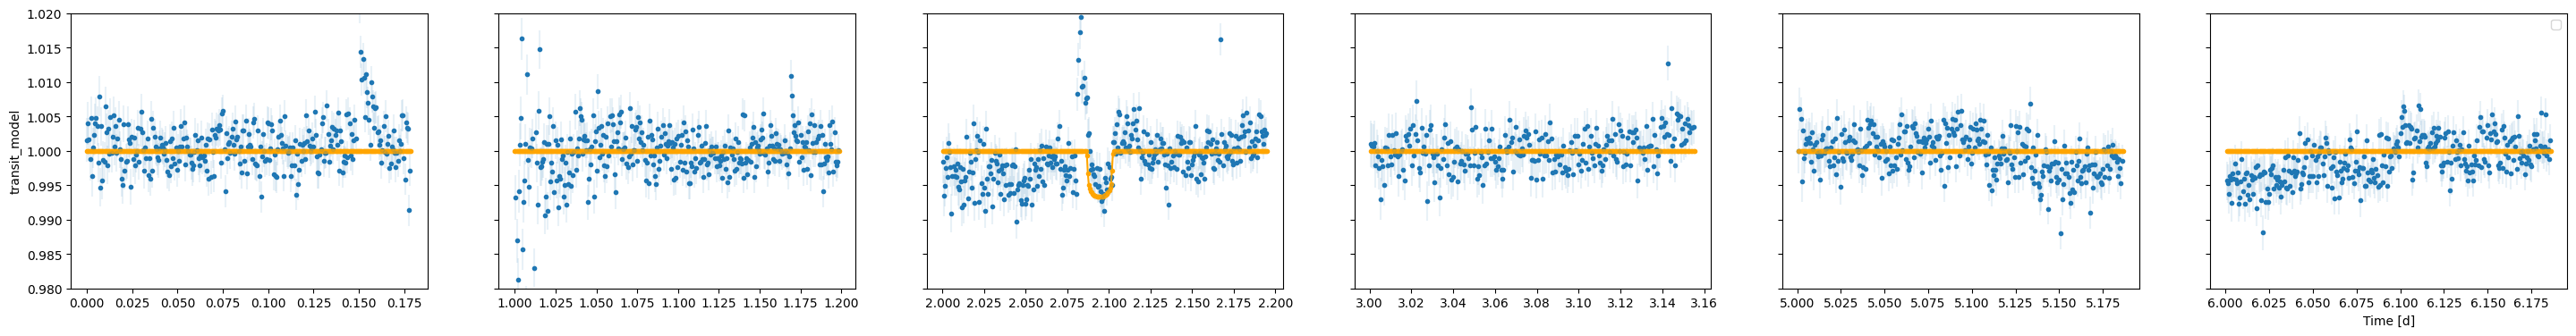

In [31]:
i=4
ax=lcs[i].plot()
lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
try:
    print(lcs_bls[i][0].metadata['BLS_transits_found'])
except:
    print(False)
    pass

In [45]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0    0.1 solRad
1    0.1 solRad
2    0.1 solRad
3    0.1 solRad
4    0.1 solRad
Name: r_s, dtype: object

Text(0.5, 0, 'Planet Radius [R_earth]')

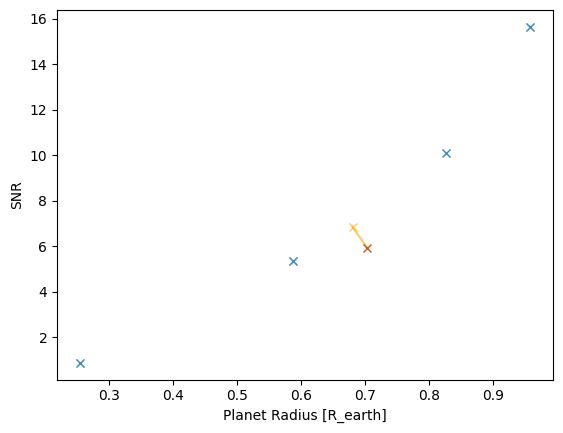

In [46]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


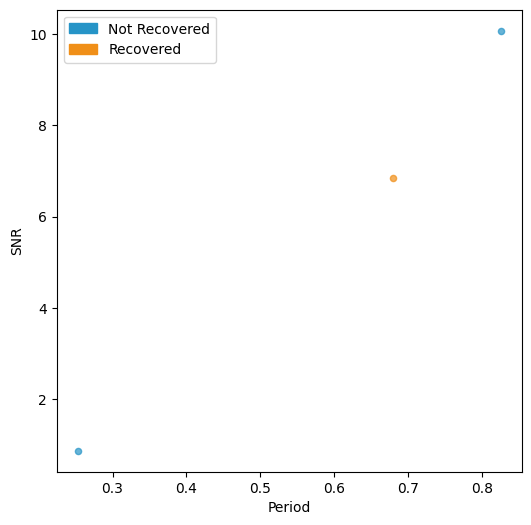

In [33]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=20,
                   svname="")